# Actividad 01: Análisis Exploratorio de Datos (EDA)

## Contexto del conjunto de datos

El conjunto de datos utilizado en este notebook corresponde a información académica y/o institucional de estudiantes, recopilada con fines de análisis descriptivo y exploratorio.  
El objetivo principal del dataset es permitir el estudio de características generales de los estudiantes y analizar posibles patrones, diferencias y relaciones entre variables relevantes.

Este análisis no busca construir modelos predictivos ni realizar inferencia estadística avanzada, sino **comprender la estructura de los datos**, identificar comportamientos generales y apoyar la toma de decisiones basada en evidencia.



## Descripción de las variables

A continuación se describen las principales columnas presentes en el conjunto de datos:

| Variable | Tipo | Descripción |
|--------|------|-------------|
| `id` | Identificador | Identificador único del estudiante (anonimizado). |
| `sexo` | Categórica | Sexo declarado del estudiante. |
| `edad` | Numérica | Edad del estudiante al momento del registro. |
| `region` | Categórica | Región de procedencia del estudiante. |
| `ptje_lenguaje` | Numérica | Puntaje obtenido en la prueba de Lenguaje. |
| `ptje_matematica` | Numérica | Puntaje obtenido en la prueba de Matemática. |
| `promedio_notas` | Numérica | Promedio de notas previo al ingreso. |
| `situacion_academica` | Categórica | Clasificación general del estado académico del estudiante. |
| `riesgo` | Categórica | Clasificación de riesgo académico (por ejemplo: bajo, medio, alto). |

Las variables pueden ser de tipo numérico o categórico, lo que permite aplicar distintos enfoques de análisis exploratorio, tales como estadísticas descriptivas, análisis de distribuciones y comparaciones entre grupos.



## Consideraciones importantes

- El dataset puede contener valores faltantes o atípicos.
- No todas las variables tienen el mismo peso o relevancia analítica.
- Las interpretaciones deben basarse exclusivamente en los resultados observados en tablas y gráficos.
- No se deben realizar supuestos externos al conjunto de datos.

A partir de este contexto, se desarrollará el análisis exploratorio que será objeto de interpretación en la actividad asociada a este notebook.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
# Lectura de datos
df = pd.read_csv("d_data.csv")
df.head()

,id,year,gender,school_dependence,ivm_colegio,nem,nem_score,rank_score,ptje_ponderado,ptje_leng_paes,ptje_m1_paes,ptje_m2_paes,alerta_cero,deserta,target
0,1,2024,M,Particular Subvencionado,0.000000,6.13,751.0,784.0,757.25,865.0,995.0,862.0,Riesgo Bajo,0.0,0
1,2,2023,F,Particular Subvencionado,14.542644,6.30,799.0,829.0,681.00,877.0,691.0,507.0,Riesgo Mínimo,0.0,0
2,3,2023,M,Particular Subvencionado,17.214484,6.10,742.0,762.0,622.80,861.0,569.0,426.0,Riesgo Alto,0.0,1
3,4,2024,M,Particular Subvencionado,0.000000,6.63,893.0,909.0,795.20,925.0,992.0,858.0,Riesgo Bajo,0.0,0
4,5,2023,M,Particular Subvencionado,12.951090,5.90,685.0,686.0,726.05,854.0,963.0,802.0,Riesgo Bajo,0.0,0


In [3]:
# Exploración inicial del dataset
df.shape

(7543, 15)

In [4]:
# Exploración inicial del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7543 entries, 0 to 7542
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7543 non-null   int64  
 1   year               7543 non-null   int64  
 2   gender             7543 non-null   object 
 3   school_dependence  7543 non-null   object 
 4   ivm_colegio        7543 non-null   float64
 5   nem                7543 non-null   float64
 6   nem_score          7543 non-null   float64
 7   rank_score         7543 non-null   float64
 8   ptje_ponderado     7543 non-null   float64
 9   ptje_leng_paes     7543 non-null   float64
 10  ptje_m1_paes       7543 non-null   float64
 11  ptje_m2_paes       7543 non-null   float64
 12  alerta_cero        7543 non-null   object 
 13  deserta            7543 non-null   float64
 14  target             7543 non-null   int64  
dtypes: float64(9), int64(3), object(3)
memory usage: 884.1+ KB


In [5]:
# Exploración inicial del dataset
df.describe()

,id,year,ivm_colegio,nem,nem_score,rank_score,ptje_ponderado,ptje_leng_paes,ptje_m1_paes,ptje_m2_paes,deserta,target
count,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000
mean,3772.000000,2023.888241,5.691552,6.243967,783.571656,809.773432,680.702313,804.815060,773.490521,623.231738,0.166379,0.550709
std,2177.620873,0.811675,8.350457,0.409986,117.083966,131.346971,83.348623,115.380889,183.961043,187.173168,0.372446,0.497455
min,1.000000,2023.000000,0.000000,5.000000,415.000000,415.000000,500.100000,377.000000,336.000000,245.000000,0.000000,0.000000
25%,1886.500000,2023.000000,0.000000,5.950000,700.000000,717.000000,617.250000,737.000000,601.000000,451.000000,0.000000,0.000000
50%,3772.000000,2024.000000,0.000000,6.300000,799.000000,827.000000,689.700000,829.000000,796.000000,596.000000,0.000000,1.000000
75%,5657.500000,2025.000000,14.794529,6.580000,879.000000,915.000000,747.050000,888.000000,967.000000,810.000000,0.000000,1.000000
max,7543.000000,2025.000000,33.169034,7.000000,1000.000000,1000.000000,882.500000,1000.000000,1000.000000,985.000000,1.000000,1.000000


In [6]:
# Exploración inicial del dataset
df.isna().sum()

id                   0
year                 0
gender               0
school_dependence    0
ivm_colegio          0
nem                  0
nem_score            0
rank_score           0
ptje_ponderado       0
ptje_leng_paes       0
ptje_m1_paes         0
ptje_m2_paes         0
alerta_cero          0
deserta              0
target               0
dtype: int64

In [15]:
# Separación por tipo de variable
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print(f"Columnas numéricas: {num_cols}\n")
print(f"Columnas categóricas: {cat_cols}")

Columnas numéricas: Index(['id', 'year', 'ivm_colegio', 'nem', 'nem_score', 'rank_score',
       'ptje_ponderado', 'ptje_leng_paes', 'ptje_m1_paes', 'ptje_m2_paes',
       'deserta', 'target'],
      dtype='object')

Columnas categóricas: Index(['gender', 'school_dependence', 'alerta_cero'], dtype='object')


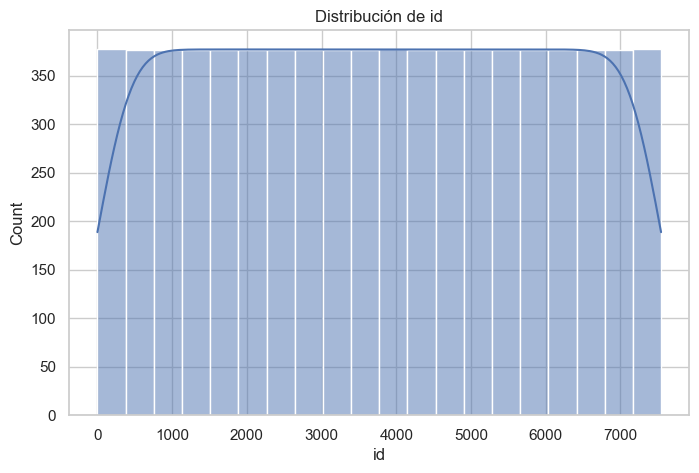

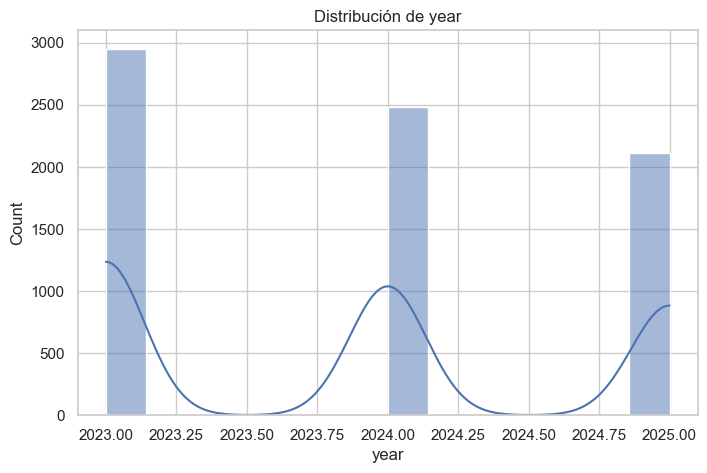

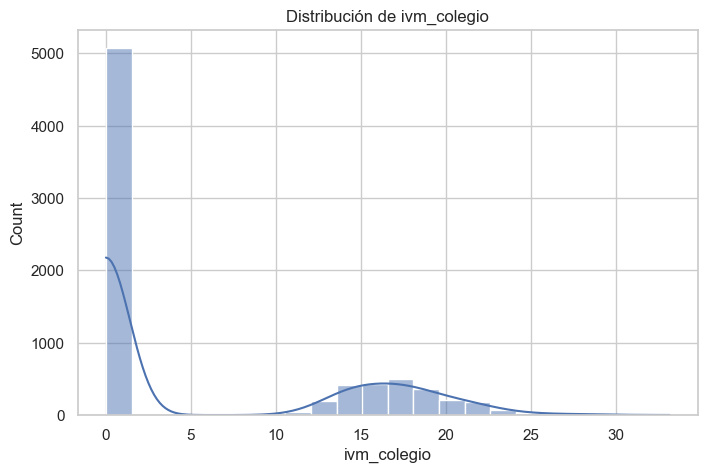

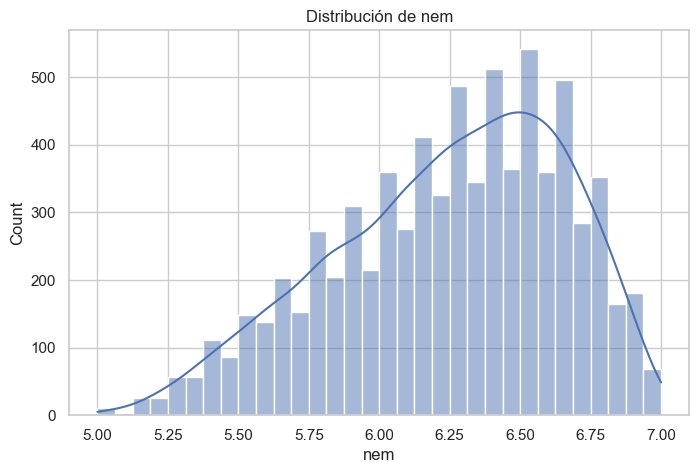

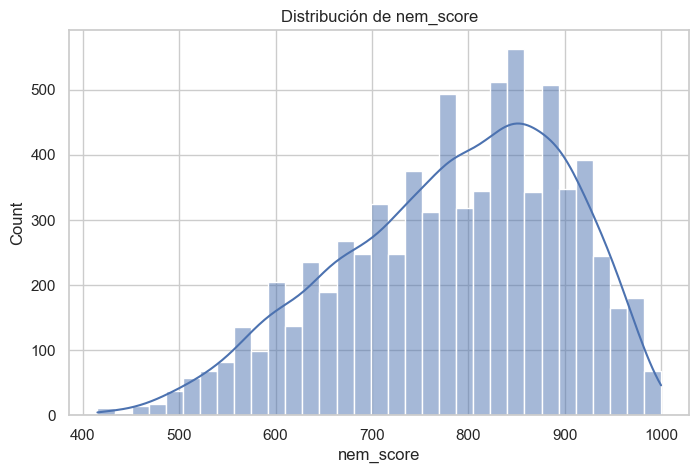

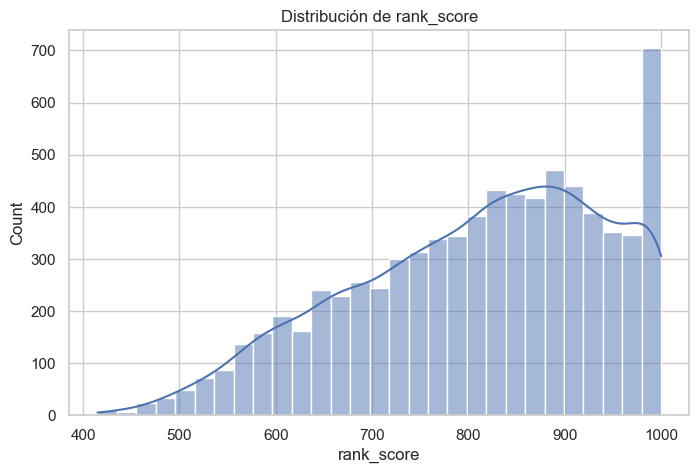

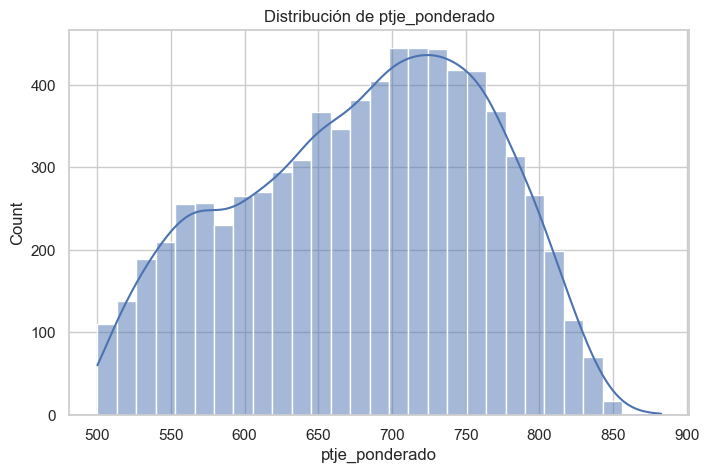

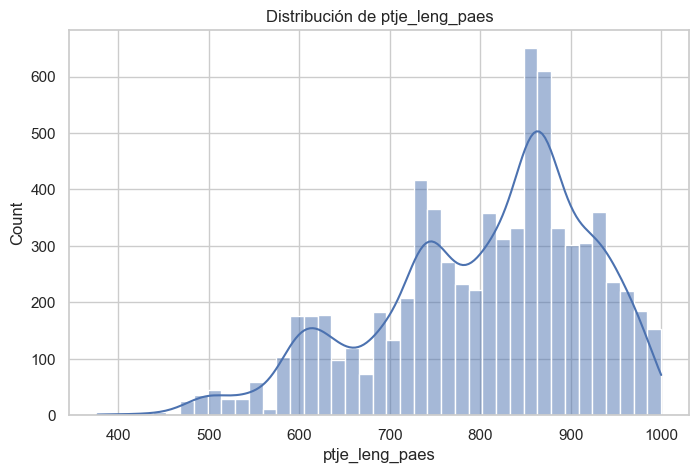

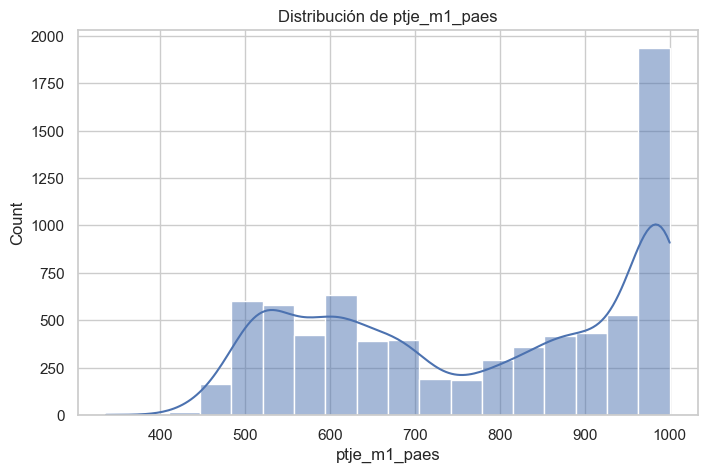

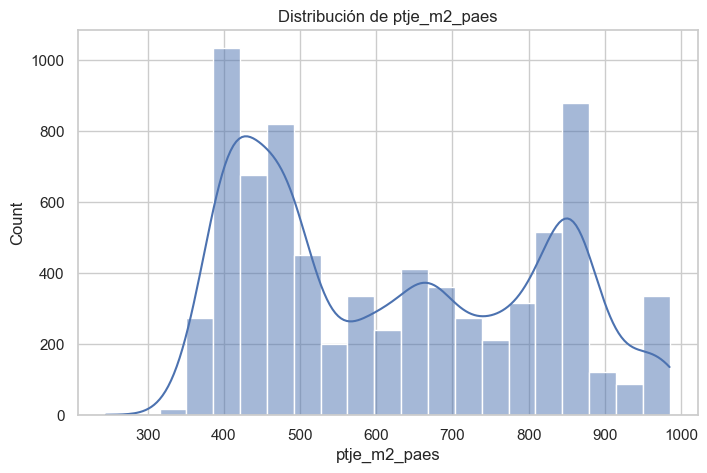

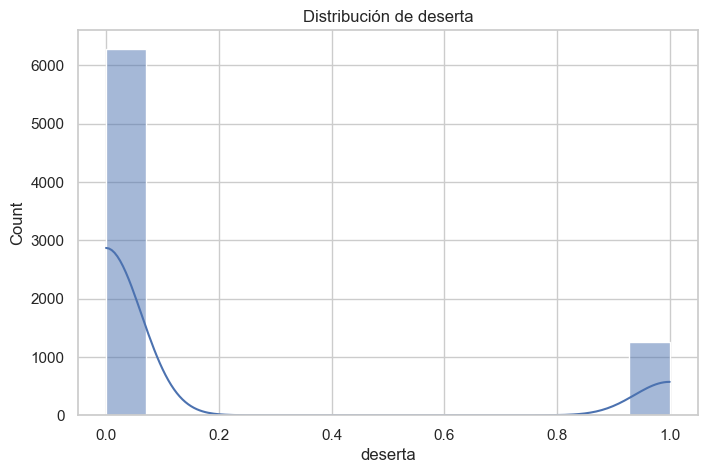

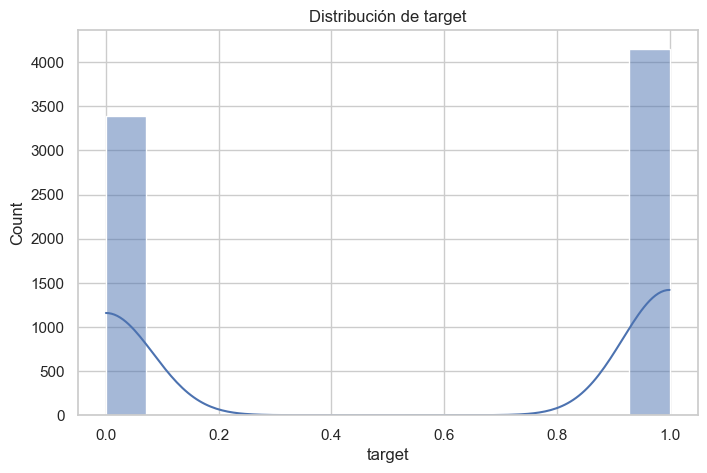

In [ ]:
# Análisis univariado – variables numéricas
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

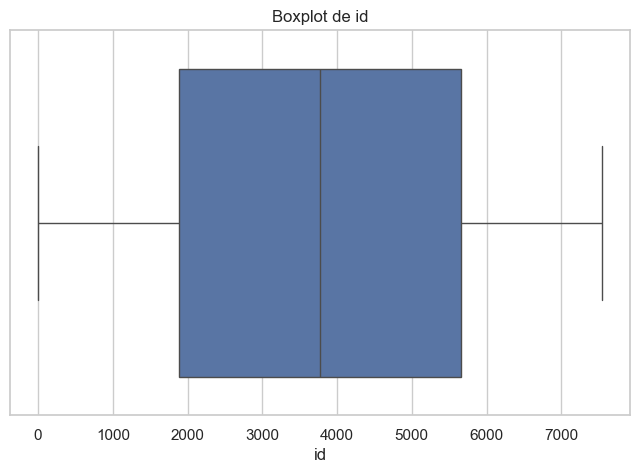

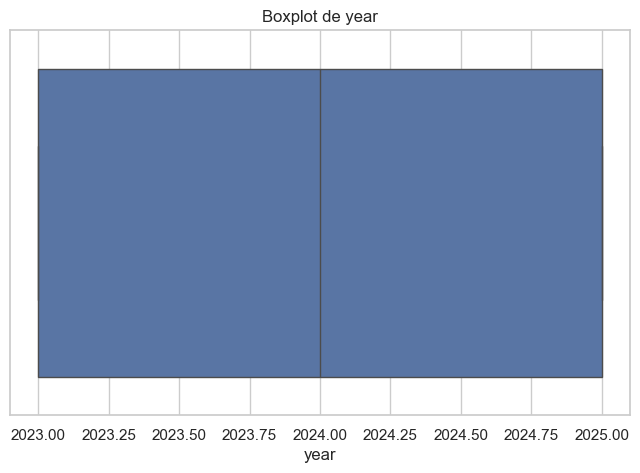

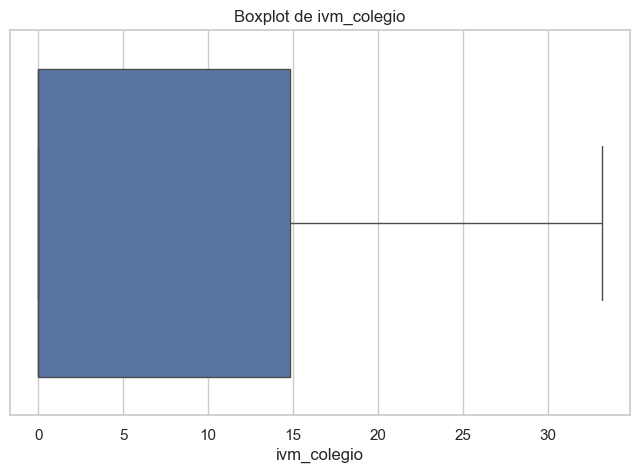

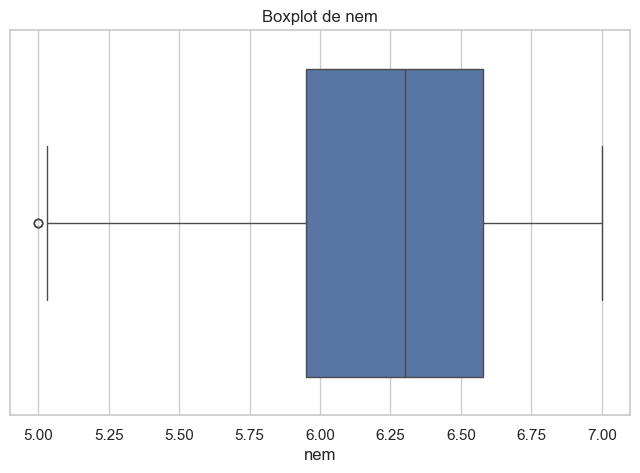

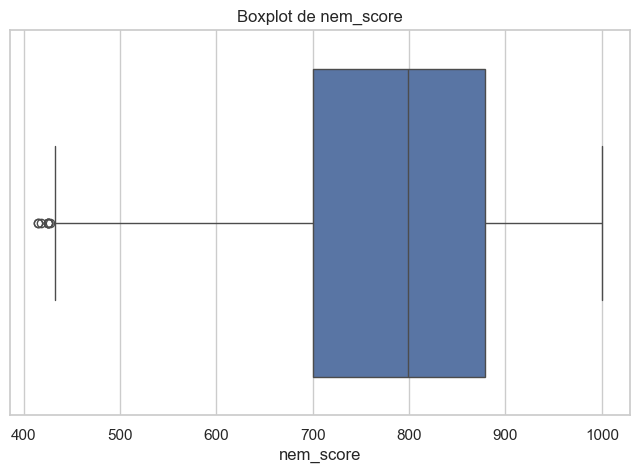

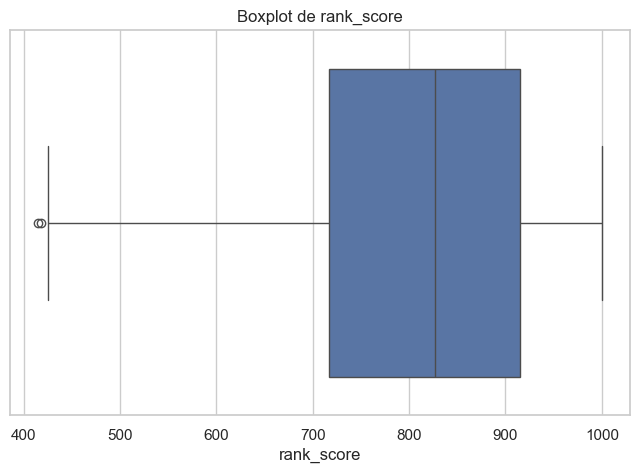

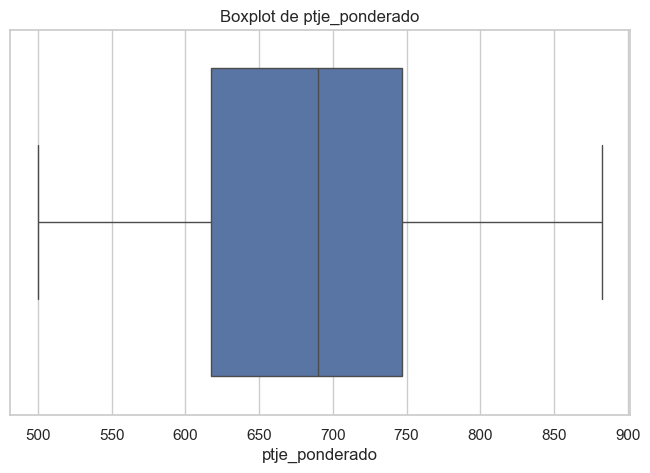

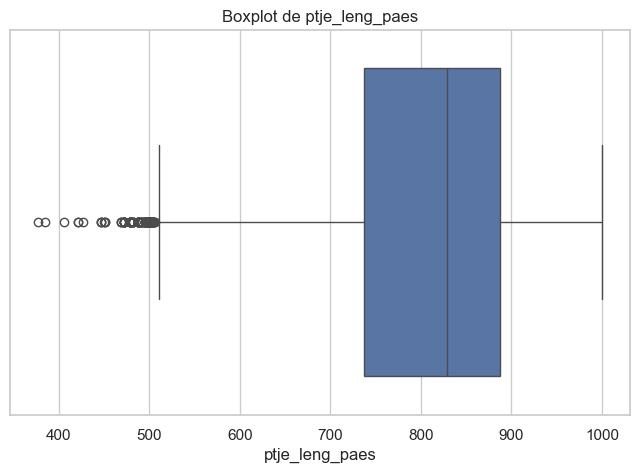

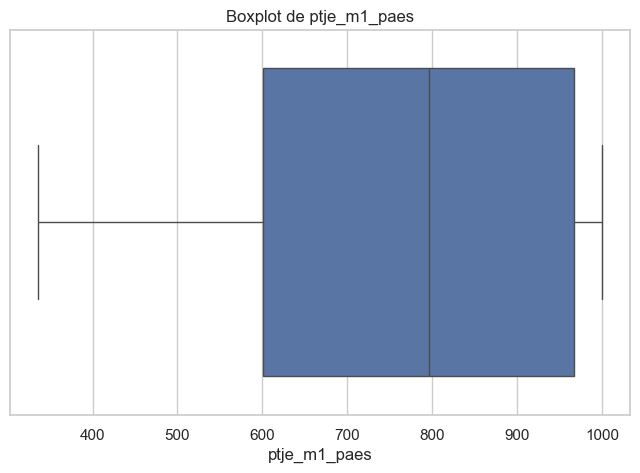

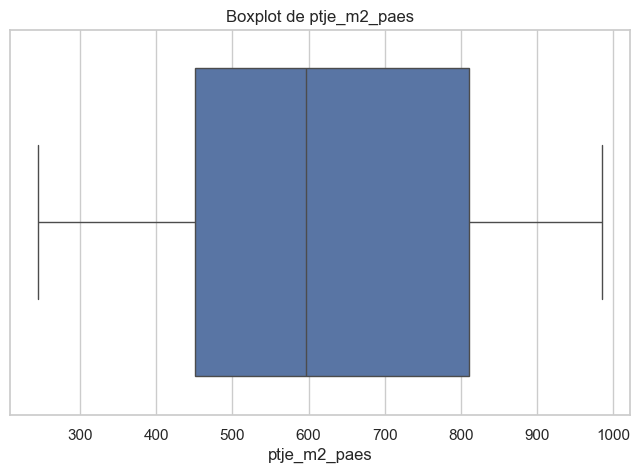

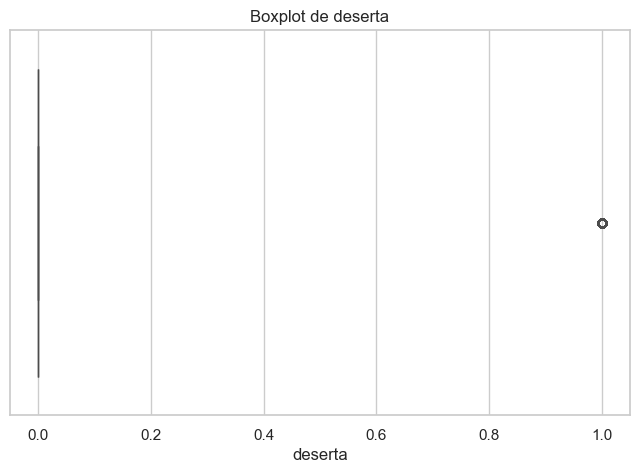

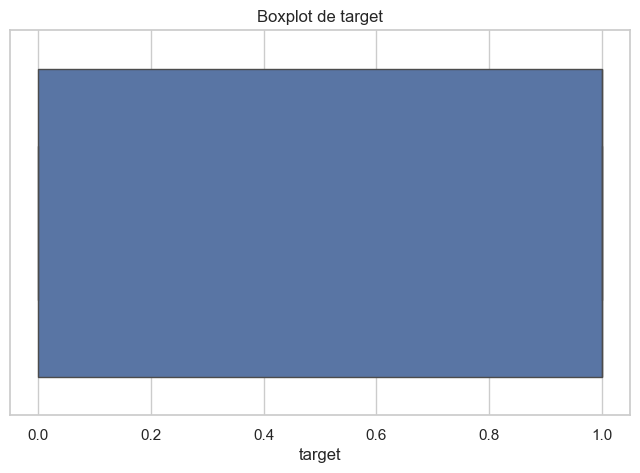

In [ ]:
# Boxplots (detección visual de outliers)
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

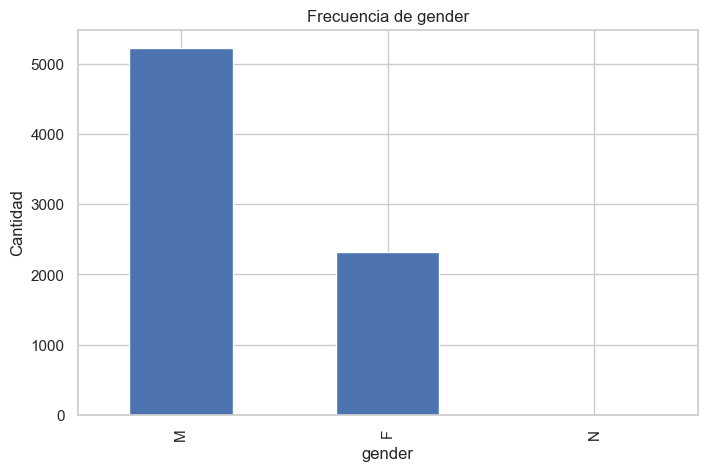

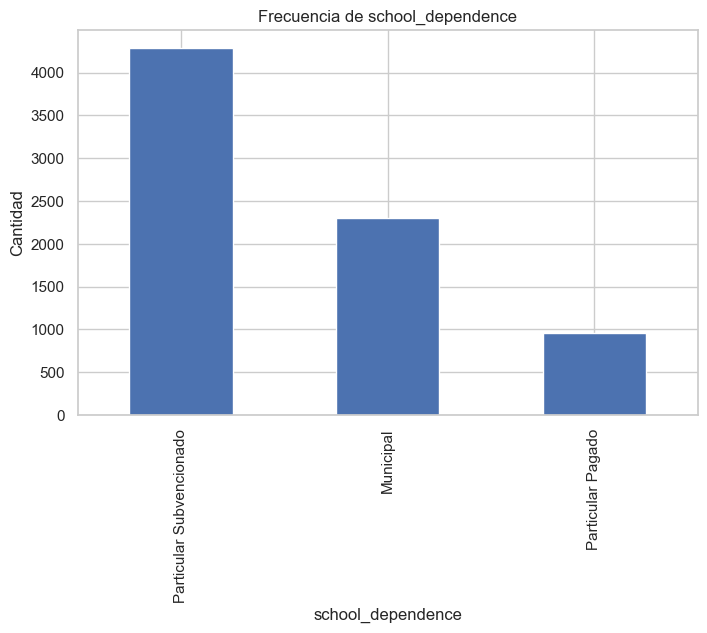

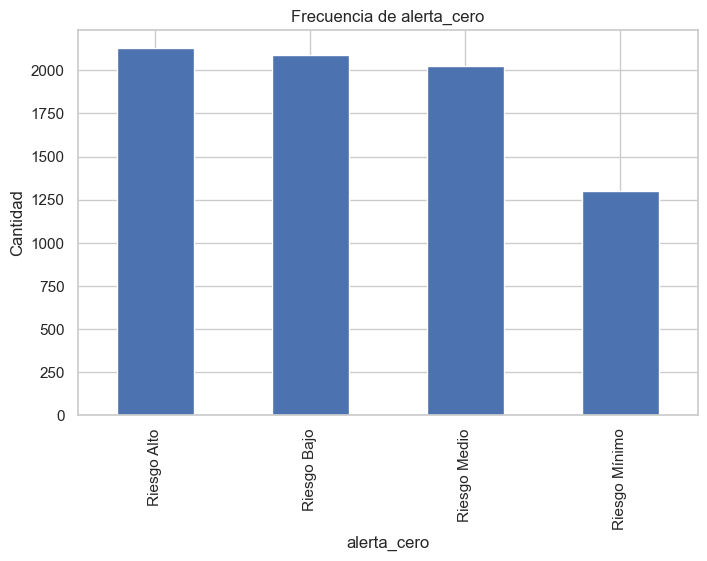

In [11]:
# Análisis univariado – variables categóricas
for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Frecuencia de {col}")
    plt.ylabel("Cantidad")
    plt.show()

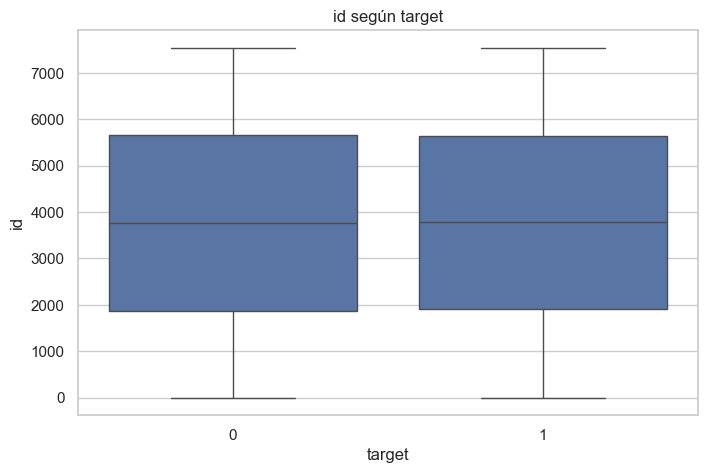

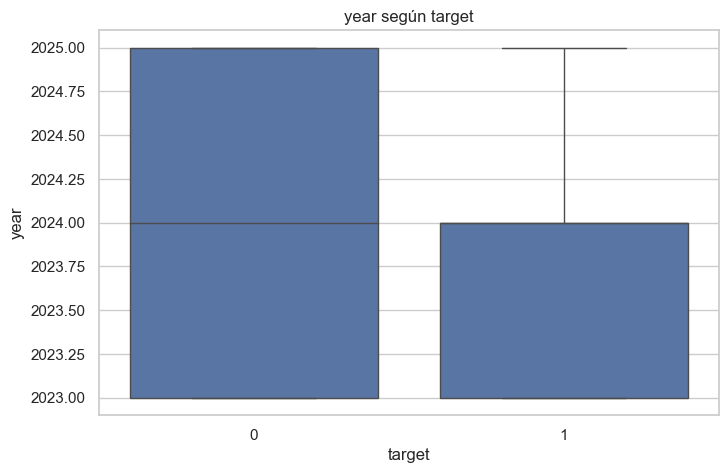

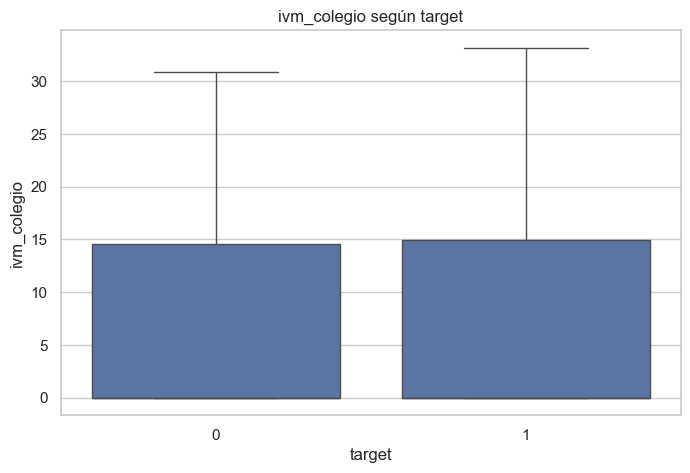

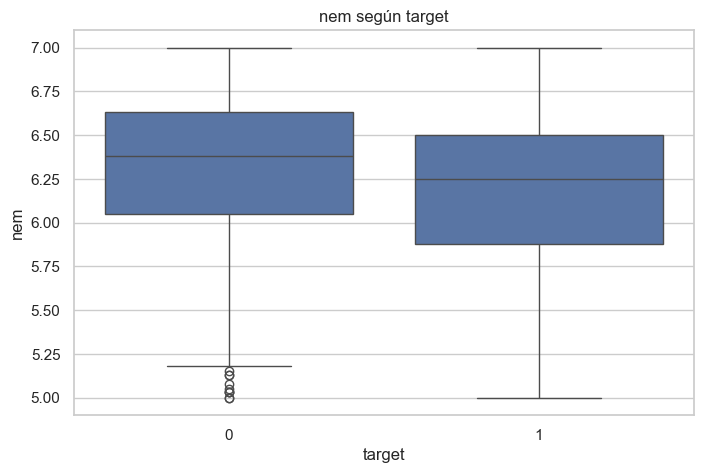

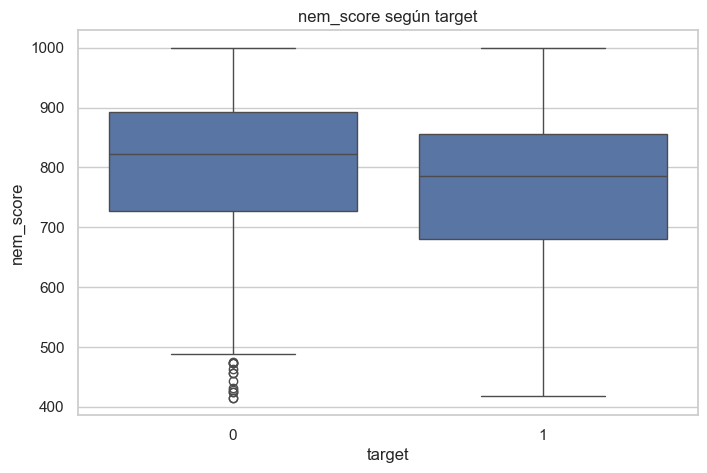

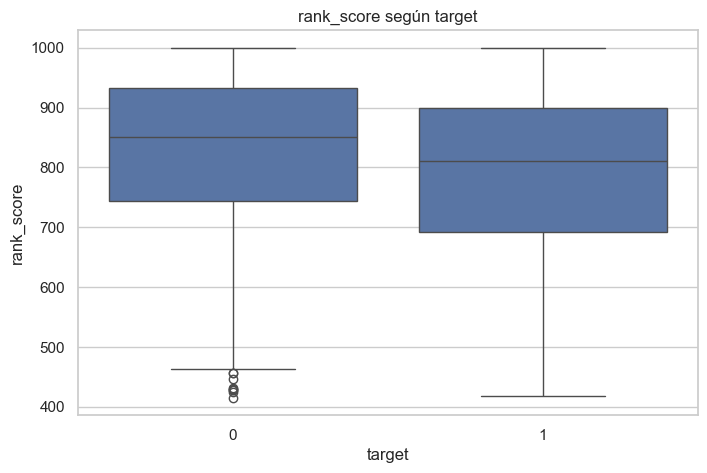

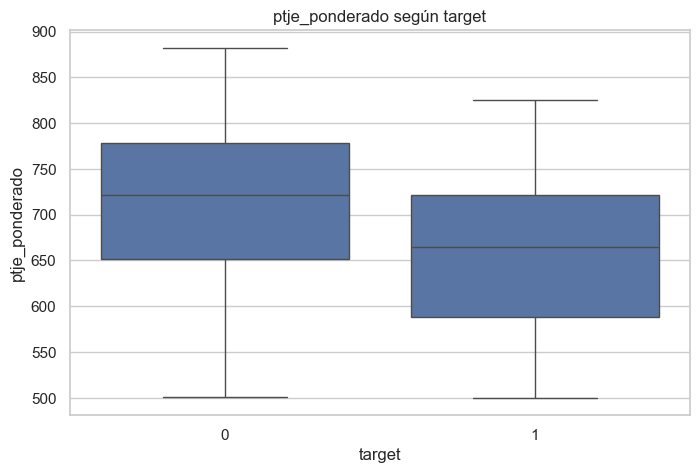

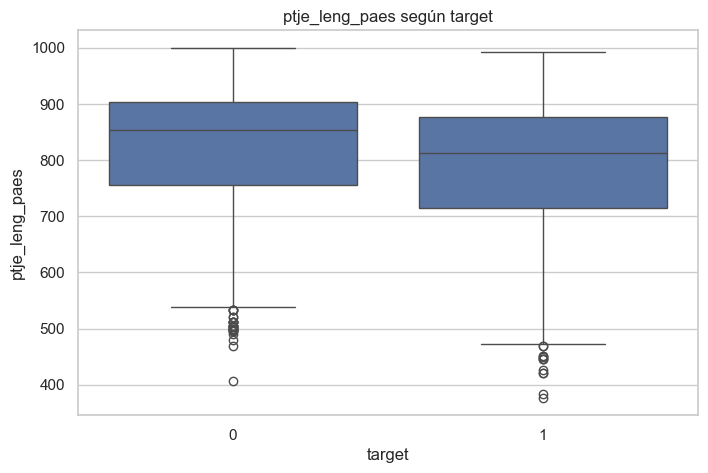

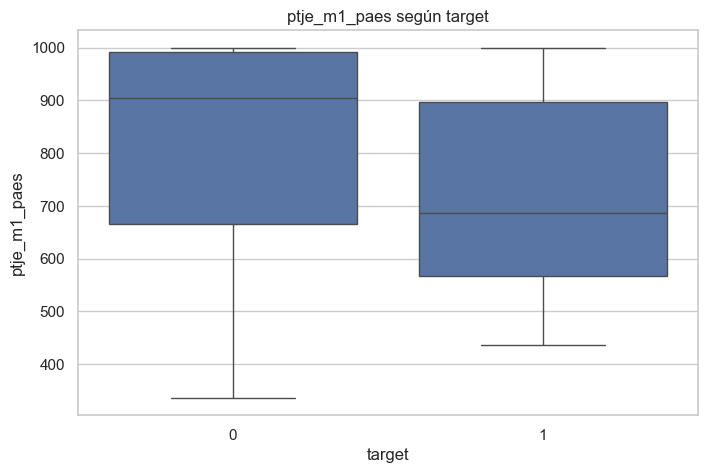

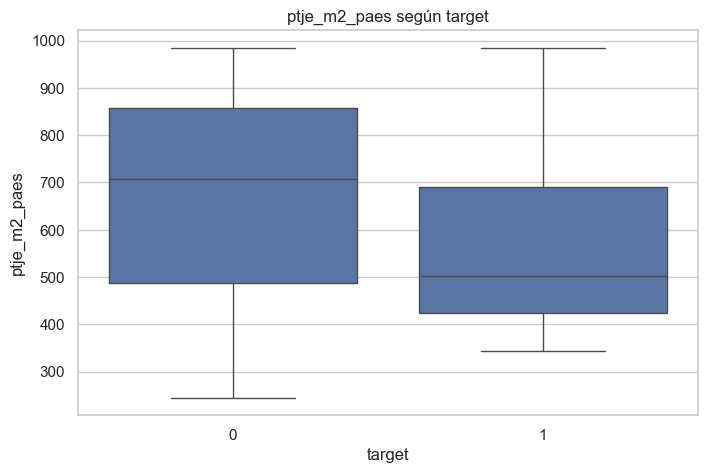

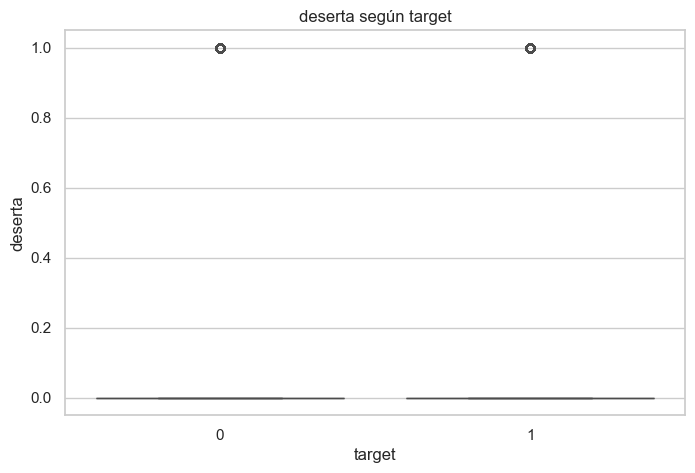

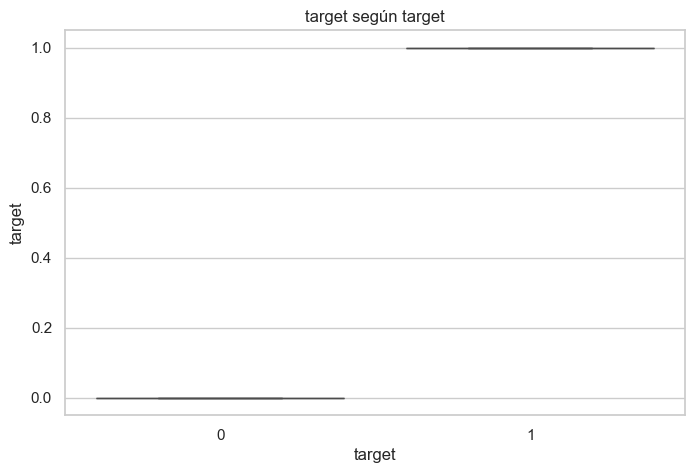

In [12]:
# Análisis bivariado (si hay variable objetivo)
# Numérica vs categórica (ejemplo)

# Cambiar 'target' por la variable correspondiente
if 'target' in df.columns:
    for col in num_cols:
        plt.figure()
        sns.boxplot(x=df['target'], y=df[col])
        plt.title(f"{col} según target")
        plt.show()

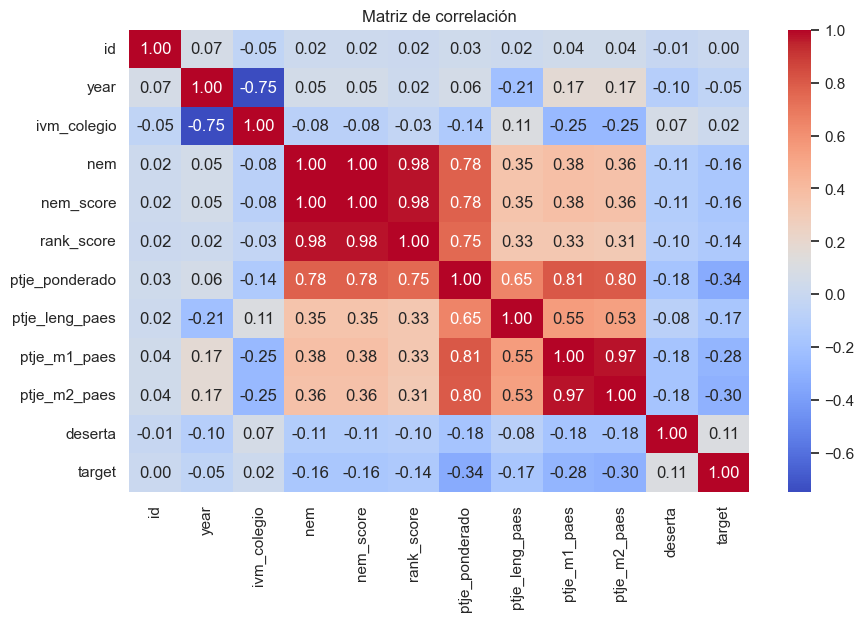

In [13]:
# Correlaciones (solo numéricas)
corr = df[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()


> Conclusiones, comentarios y anotaciones: ...